In [28]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_arch
import statsmodels.api as sm

In [24]:
df = pd.read_csv("dataset_propre.csv", index_col=0, parse_dates=True)

split = int(len(df) * 0.8)
train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

--- 1. TEST DE STATIONNARITÉ ---
P-value du test ADF : 0.00000
-> La série est stationnaire (d=0).

--- 2. IDENTIFICATION DES PARAMÈTRES (ACF / PACF) ---


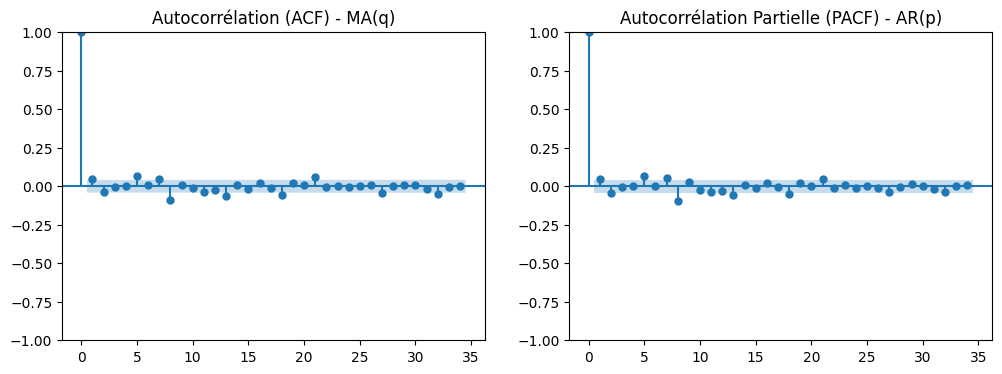

In [25]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

print("--- 1. TEST DE STATIONNARITÉ ---")
resultat_adf = adfuller(train['Cible'])
print(f"P-value du test ADF : {resultat_adf[1]:.5f}")
if resultat_adf[1] < 0.05:
    print("-> La série est stationnaire (d=0).")
else:
    print("-> La série n'est pas stationnaire, différenciation requise.")

print("\n--- 2. IDENTIFICATION DES PARAMÈTRES (ACF / PACF) ---")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train['Cible'], ax=ax[0], title="Autocorrélation (ACF) - MA(q)")
plot_pacf(train['Cible'], ax=ax[1], title="Autocorrélation Partielle (PACF) - AR(p)")
plt.show()

### Justification des paramètres ARIMA(p,d,q)

Avant d'entraîner notre modèle, nous devons identifier ses paramètres optimaux :
* **Ordre d'intégration (d=0) :** Le test de Dickey-Fuller Augmenté (ADF) rejette l'hypothèse nulle de racine unitaire (p-value < 0.05). Nos rendements journaliers sont déjà stationnaires, nous n'avons donc pas besoin de les différencier.
* **Ordre Auto-Régressif et Moyenne Mobile (p=1, q=1) :** La lecture des corrélogrammes (ACF et PACF) montre une décroissance très rapide et un seul premier "lag" (retard) véritablement significatif, caractéristique des rendements financiers à haute fréquence. 

Pour éviter le sur-apprentissage (overfitting) et capturer uniquement la dynamique de base de court terme, nous sélectionnons donc le modèle parcimonieux **ARIMA(1,0,1)**.

In [26]:
print("Entraînement ARIMA")
modele_arima = ARIMA(train['Cible'], order=(1, 0, 1))
resultats = modele_arima.fit()

Entraînement ARIMA


c:\Users\Tomle\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tomle\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tomle\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [27]:
print("Calcul des prédictions et des résidus")

train['Residus_ARIMA'] = train['Cible'] - resultats.fittedvalues

test['Pred_ARIMA'] = resultats.forecast(steps=len(test)).values

train.to_csv("train_avec_arima.csv")
test.to_csv("test_avec_arima.csv")

print("Génération terminée")
train[['Cible', 'Residus_ARIMA']].head()

Calcul des prédictions et des résidus
Génération terminée


c:\Users\Tomle\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Tomle\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,Cible,Residus_ARIMA
Date,,
2015-01-07,0.009699,0.009239
2015-01-08,0.026837,0.025951
2015-01-09,-0.021558,-0.023057
2015-01-12,-0.008770,-0.007694
2015-01-13,0.011008,0.010252


EXTRACTION DES RÉSIDUS
Résidus extraits avec succès.

DIAGNOSTICS STATISTIQUES
Kurtosis (Épaisseur des queues) : 13.52 (Une loi normale = 0)
Test de Jarque-Bera (p-value)   : 0.00000
Test ARCH-LM (p-value)          : 0.00000
AFFICHAGE GRAPHIQUE


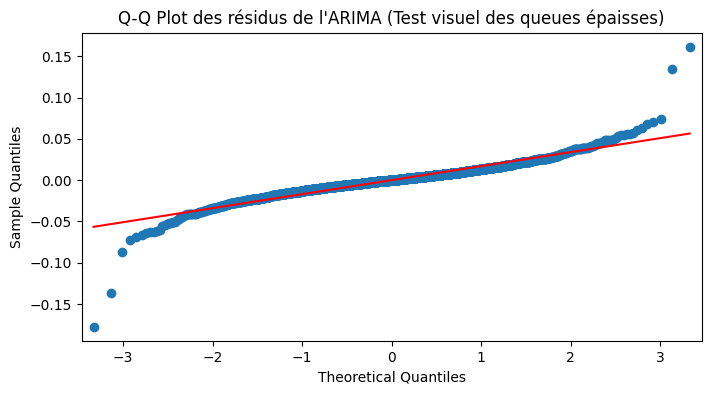

In [ ]:
print("EXTRACTION DES RÉSIDUS")

train['Residus_ARIMA'] = resultats.resid
residus = train['Residus_ARIMA'].dropna()
print("Résidus extraits avec succès.\n")

print("DIAGNOSTICS STATISTIQUES")

jb_stat, jb_p_value = stats.jarque_bera(residus)
kurtosis = stats.kurtosis(residus)
print(f"Kurtosis (Épaisseur des queues) : {kurtosis:.2f} (Une loi normale = 0)")
print(f"Test de Jarque-Bera (p-value)   : {jb_p_value:.5f}")

arch_stat, arch_p_value, _, _ = het_arch(residus)
print(f"Test ARCH-LM (p-value)          : {arch_p_value:.5f}")

print("AFFICHAGE GRAPHIQUE")
plt.rc("figure", figsize=(8, 4))
sm.qqplot(residus, line='s')
plt.title("Q-Q Plot des résidus de l'ARIMA (Test visuel des queues épaisses)")
plt.show()

### Analyse des Résidus : Les limites de l'économétrie linéaire et la justification du Machine Learning

L'objectif de notre modèle ARIMA(1,0,1) était de filtrer l'autocorrélation linéaire des rendements. Cependant, l'analyse statistique de ses erreurs (les résidus) démontre de manière implacable pourquoi le modèle échoue:

1. **Présence massive de queues épaisses (Fat Tails) :** 
   Le Kurtosis atteint un niveau exceptionnellement élevé de 13.52 (contre 0 pour une loi normale), et le test de Jarque-Bera rejette formellement l'hypothèse de normalité avec une p-value de 0.00000. Visuellement, le Q-Q Plot confirme ce constat : aux extrémités du graphique, les points bleus se détachent violemment de la ligne rouge théorique. La plongée des points dans le coin inférieur gauche indique que les chocs négatifs extrêmes (les krachs) sont infiniment plus fréquents et sévères que ce que prévoit la statistique classique.

2. **Hétéroscédasticité Conditionnelle (Volatility Clustering) :**
   Le test ARCH-LM rejette également l'hypothèse de variance constante (p-value = 0.00000). Cela prouve qu'il reste des "grappes de volatilité" dans nos résidus : les jours de forte turbulence ont tendance à se regrouper. L'ARIMA est aveugle à cette dynamique.

**Conclusion stratégique :**
L'économétrie a fait son maximum, mais elle laisse intacte la structure complexe et asymétrique des risques extrêmes. C'est exactement pour combler cette faille que nous allons désormais injecter ces résidus non-linéaires dans un algorithme de Machine Learning (XGBoost), afin d'apprendre à anticiper ces fameuses "Fat Tails" à partir de nos variables macroéconomiques.